# 10 — Final held-out 2020 evaluation

## Headline result: probabilistic six-horizon forecasting with 22.44% lower 30-minute MAE than AEMO P5MIN

The final comparison contains only the model selected from 2019 development evidence and the external AEMO P5MIN benchmark. Both are scored at the equivalent 30-minute horizon on 105,400 common 2020 forecast origins.

## Frozen evaluation protocol

`TCN_starNLL_noSD` was selected using 2019 validation only. Its seed 42, 142, and 242 members were then refitted on 2015–2019 for exactly 10 epochs, frozen, and combined as an equal-weight Student-t mixture before 2020 was scored. No other development candidate is ranked on the final period. AEMO is retained only as the independently published operational benchmark.

## What the probabilistic head adds

At each of the 5, 10, 15, 20, 25, and 30-minute horizons, every ensemble member predicts a Student-t location, scale, and degrees of freedom. The three member densities are combined as an equal-weight mixture, providing a full predictive distribution rather than only a point estimate. That distribution supports prediction intervals, tail-risk measures, and probabilities of operational thresholds.

**Illustrative example.** If current demand is 7,000 MW and a 30-minute head has a change location of +120 MW, scale of 60 MW, and 5 degrees of freedom, the point forecast is 7,120 MW. The same Student-t head assigns approximately 12% probability to demand exceeding 7,200 MW, because that event is `change > 200 MW`. These values are explanatory only and are not a selected evaluation row.

## Headline 30-minute comparison

| rank_by_mae | model | role | forecast_origins | mae_30m_mw | rmse_30m_mw | bias_30m_mw | mae_gain_vs_aemo_percent |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | TCN_starNLL_noSD three-seed ensemble | 2019-selected champion | 105400 | 47.355 | 64.308 | 2.672 | 22.440 |
| 2 | AEMO P5MIN external benchmark | external benchmark | 105400 | 61.056 | 81.256 | -1.095 | 0.000 |

The extension ensemble reduces 30-minute MAE from 61.056 MW to 47.355 MW: an absolute reduction of 13.701 MW and a relative gain of **22.44%**. The percentage is `(AEMO MAE - model MAE) / AEMO MAE × 100`, evaluated only on the common study-period origins.

,rank_by_mae,model,role,forecast_origins,mae_30m_mw,rmse_30m_mw,bias_30m_mw,mae_gain_vs_aemo_percent
0,1,TCN_starNLL_noSD three-seed ensemble,2019-selected champion,105400,47.3549,64.3077,2.6718,22.4402
1,2,AEMO P5MIN external benchmark,external benchmark,105400,61.0560,81.2563,-1.0950,0.0000


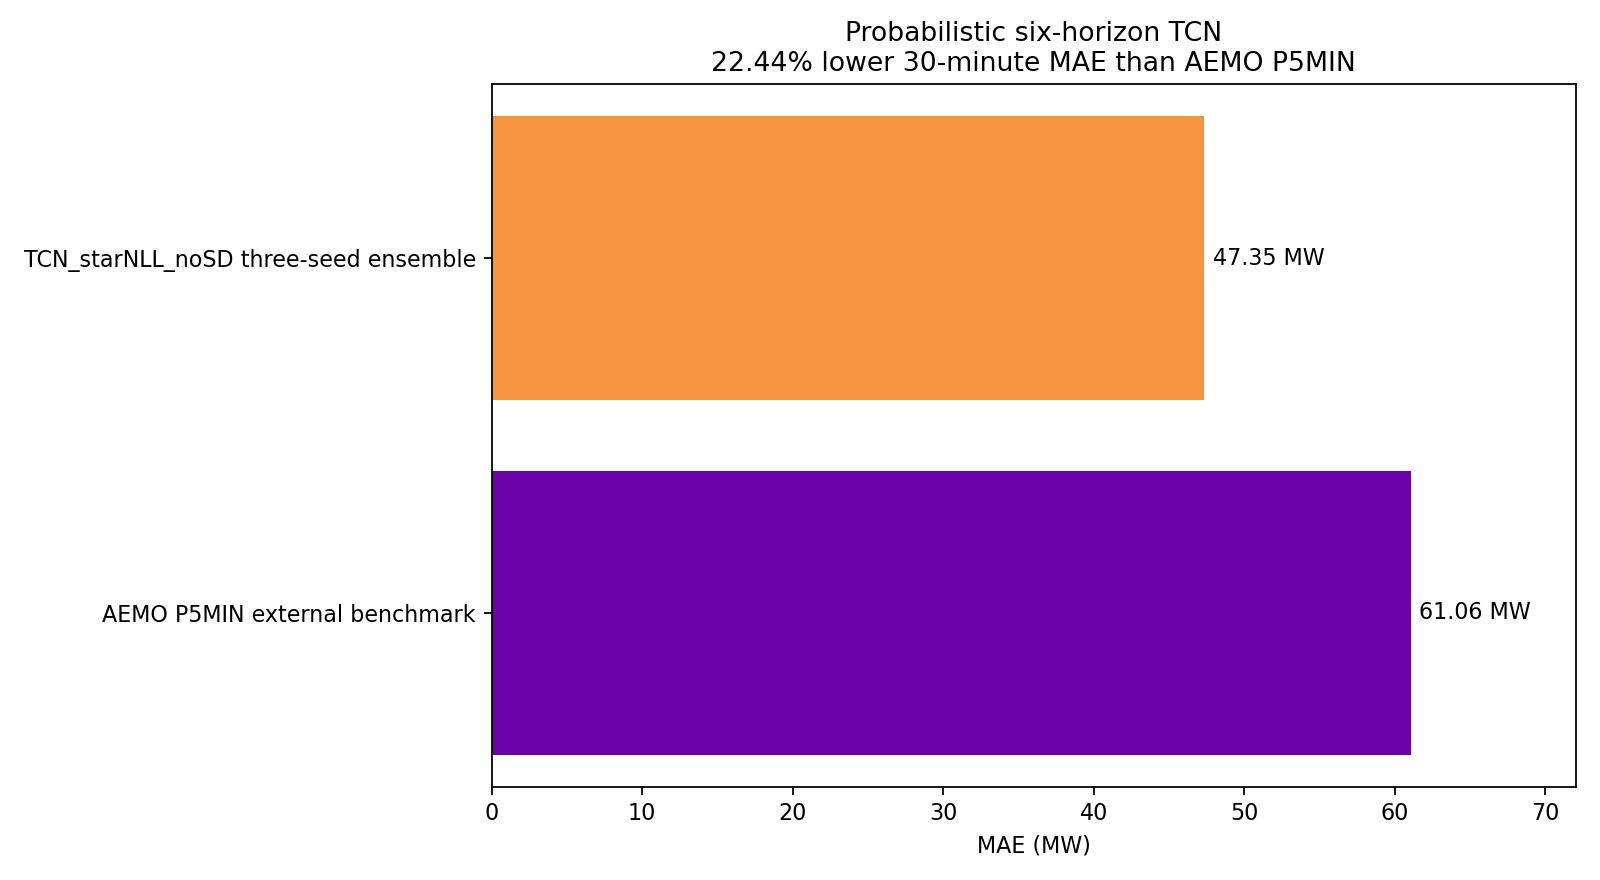

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'outputs' / '10_final_2020_evaluation').is_dir())
OUT = ROOT / 'outputs' / '10_final_2020_evaluation'
display(pd.read_csv(OUT / 'endpoint_30m_model_comparison_2020.csv').round(4))
display(Image(filename=str(OUT / 'endpoint_30m_mae_2020.png')))